In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
import os
import urllib.request
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data_path = "input.txt"
urllib.request.urlretrieve(url, data_path)
with open(data_path, 'r', encoding = 'utf-8') as file:
    text  = file.read()
char = sorted(list(set(text)))
vocab_size  =len(char)
char_2_int = {ch:i for i,ch in enumerate(char)}
int_2_char = {i:ch for i,ch in enumerate(char)}
encode = lambda x: [char_2_int[c] for c in x]
decode = lambda x : ''.join([int_2_char[i] for i in x])
data  = torch.tensor(encode(text), dtype = torch.long)
n = int(.9 * len(data))
train = data[:n]
validation = data[n:]
print(f"Vocab size : {vocab_size}\n Train data : {len(train)} Validation data : {len(validation)}")

Vocab size : 65
 Train data : 1003854 Validation data : 111540


In [4]:
len(data)

1115394

In [33]:
class CausalAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.per_head = d_model // n_heads
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
    def forward(self, x):
        Batch, seq_len,d_model = x.shape
        residual = x
        q, k, v = self.c_attn(x).split(self.d_model, dim=2)
        q = q.view(Batch, seq_len, self.n_heads, self.per_head).transpose(1, 2)
        k = k.view(Batch, seq_len, self.n_heads, self.per_head).transpose(1, 2)
        v = v.view(Batch, seq_len, self.n_heads, self.per_head).transpose(1, 2)
        qk = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.per_head)
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).view(1, 1,seq_len,seq_len)
        qk = qk.masked_fill(mask == 0, float('-inf'))
        weights = F.softmax(qk, dim=-1)
        context = torch.matmul(weights, v)

        context = context.transpose(1, 2).contiguous().view(Batch,seq_len,d_model)
        return self.c_proj(context)

In [34]:
class FFN(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.ffn = nn.Sequential(nn.Linear(d_model, 4 * d_model),nn.GELU(),nn.Linear(4 * d_model, d_model))
    def forward(self, x):
        return self.ffn(x)

In [60]:
class Transformation(nn.Module):
  def __init__(self,d_model,n_heads):
    super().__init__()
    self.ln1 = nn.LayerNorm(d_model)
    self.attn = CausalAttention(d_model,n_heads)
    self.ln2  = nn.LayerNorm(d_model)
    self.ffn = FFN(d_model)
  def forward(self,x):
    x = x + self.attn(self.ln1(x))
    x = x + self.ffn(self.ln2(x))
    return x

class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size, n_layer, d_model, n_heads, block_size):
        super().__init__()
        self.block_size = block_size
        self.token_embeddings = nn.Embedding(vocab_size, d_model)
        self.position_embeddings = nn.Embedding(block_size, d_model)
        self.layers = nn.ModuleList([Transformation(d_model,n_heads) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.lm_head.weight = self.token_embeddings.weight

    def forward(self, idx, targets=None):
        Batch, seq_len = idx.shape
        pos = torch.arange(0, seq_len, dtype=torch.long, device=idx.device)
        x = self.token_embeddings(idx) + self.position_embeddings(pos)
        for layer in self.layers:
          x = layer(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [59]:
Batch, seq_len, d_model = 4, 128, 64
vocab_size = 65
x = torch.randint(0, vocab_size, (Batch,seq_len)).cuda()
model_test = DecoderTransformer(vocab_size, n_layer=2, d_model=d_model, n_heads=2, block_size=128).cuda()
logits, _ = model_test(x)
if(logits.shape == (Batch,seq_len,vocab_size)):
  print(f"Passed since dimension match")
else:
  print(logits.shape)

Passed since dimension match


In [62]:
vocab_size = 65
d_model = 64
model = DecoderTransformer(vocab_size=vocab_size, n_layer=2, d_model=d_model, n_heads=2, block_size=128).cuda()
model.train()
x_test = torch.randint(0, vocab_size, (1, 10)).cuda()
embed = []
def fxn(module, input, output):
    out = output.clone().detach().requires_grad_(True)
    embed.append(out)
    return out

fn = model.token_embeddings.register_forward_hook(fxn)
logits, _ = model(x_test)
fn.remove()
loss_at_t4 = logits[0, 4, :].sum()
loss_at_t4.backward()
embed_grad = embed[0].grad[0]
g = embed_grad.abs().sum(dim=-1)
for t in range(10):
    if t <= 4:
        print(f"Token {t} (Past/Present) -> Gradient Magnitude: {g[t].item():.6f}")
    else:
      grad = g[t].item()
      assert grad == 0.0, f" INDEX {t}! Gradient: {grad}"
      print(f"Token {t} Gradient Magnitude: {grad:.2f}")
print("\nSo gradient which are greater then t not come in backward .")

Token 0 (Past/Present) -> Gradient Magnitude: 34.454029
Token 1 (Past/Present) -> Gradient Magnitude: 29.817911
Token 2 (Past/Present) -> Gradient Magnitude: 23.520729
Token 3 (Past/Present) -> Gradient Magnitude: 24.881144
Token 4 (Past/Present) -> Gradient Magnitude: 312.970856
Token 5 Gradient Magnitude: 0.00
Token 6 Gradient Magnitude: 0.00
Token 7 Gradient Magnitude: 0.00
Token 8 Gradient Magnitude: 0.00
Token 9 Gradient Magnitude: 0.00

So gradient which are greater then t not come in backward .


In [63]:
model = DecoderTransformer(vocab_size=65, n_layer=2, d_model=64, n_heads=2, block_size=128).cuda()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
x = torch.randint(len(train) - 128, (16,))
xb = torch.stack([train[i:i+128] for i in x]).cuda()
yb = torch.stack([train[i+1:i+128+1] for i in x]).cuda()
model.train()
for step in range(501):
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if step % 100 == 0:
        print(f"  Step {step:3d} | Overfit Target Loss: {loss.item():.4f}")
print("\nThe model get imporved as it gradualy decressing the loss.")

  Step   0 | Overfit Target Loss: 40.6036
  Step 100 | Overfit Target Loss: 3.2281
  Step 200 | Overfit Target Loss: 2.4833
  Step 300 | Overfit Target Loss: 0.7541
  Step 400 | Overfit Target Loss: 0.0148
  Step 500 | Overfit Target Loss: 0.0072

The model get imporved as it gradualy decressing the loss.


In [36]:
def count_non_embedding_params(model):
    return sum(p.numel() for name, p in model.named_parameters()
               if 'embed' not in name and 'lm_head' not in name)

@torch.no_grad()
def estimate_loss(model, split, eval_iters, batch_size, block_size, custom_data=None):
    model.eval()
    losses = torch.zeros(eval_iters)
    source_data = train if split == 'train' else validation
    if custom_data is not None and split == 'train':
        source_data = custom_data

    for k in range(eval_iters):
        ix = torch.randint(len(source_data) - block_size, (batch_size,))
        x = torch.stack([source_data[i:i+block_size] for i in ix]).cuda()
        y = torch.stack([source_data[i+1:i+block_size+1] for i in ix]).cuda()
        _, loss = model(x, y)
        losses[k] = loss.item()
    model.train()
    return losses.mean().item()

In [37]:
sweep_para = [
    {"name": "Tiny", "L": 2, "d_model": 64, "H": 2, "T": 128},
    {"name": "Small", "L": 4, "d_model": 128, "H": 4, "T": 256},
    {"name": "Medium", "L": 6, "d_model": 256, "H": 8, "T": 256}
]
Para_sweep = []
for c in sweep_para:
    print(f"\n SWEEP: {c['name']} - Scale")
    model = DecoderTransformer(vocab_size=vocab_size, n_layer=c['L'], d_model=c['d_model'],n_heads=c['H'], block_size=c['T']).cuda()
    N_count = count_non_embedding_params(model)
    print(f"Non-Embedding Parameters (N): {N_count:,}")
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    validation_loss = float('inf')
    for step in range(3001):
        x = torch.randint(len(train) - c['T'], (16,))
        xb = torch.stack([train[i:i+c['T']] for i in x]).cuda()
        yb = torch.stack([train[i+1:i+c['T']+1] for i in x]).cuda()
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if step % 500 == 0 or step == 3000:
            validation_loss = estimate_loss(model, 'val', eval_iters=50, batch_size=16, block_size=c['T'])
            print(f"Step {step:4d} ,  Val Loss: {validation_loss:.4f}")
    Para_sweep.append({"N": N_count, "val_loss": validation_loss})


 SWEEP: Tiny - Scale
Non-Embedding Parameters (N): 100,096
Step    0 ,  Val Loss: 4.3234
Step  500 ,  Val Loss: 2.5155
Step 1000 ,  Val Loss: 2.4304
Step 1500 ,  Val Loss: 2.3358
Step 2000 ,  Val Loss: 2.2500
Step 2500 ,  Val Loss: 2.1678
Step 3000 ,  Val Loss: 2.1261

 SWEEP: Small - Scale
Non-Embedding Parameters (N): 793,344
Step    0 ,  Val Loss: 4.1132
Step  500 ,  Val Loss: 2.4241
Step 1000 ,  Val Loss: 2.1768
Step 1500 ,  Val Loss: 2.0055
Step 2000 ,  Val Loss: 1.9112
Step 2500 ,  Val Loss: 1.8258
Step 3000 ,  Val Loss: 1.7724

 SWEEP: Medium - Scale
Non-Embedding Parameters (N): 4,739,072
Step    0 ,  Val Loss: 3.7638
Step  500 ,  Val Loss: 2.1443
Step 1000 ,  Val Loss: 1.8479
Step 1500 ,  Val Loss: 1.7046
Step 2000 ,  Val Loss: 1.6500
Step 2500 ,  Val Loss: 1.5999
Step 3000 ,  Val Loss: 1.5787


In [38]:
percent = [0.10, 0.25, 0.50, 1.00]
data_sweep = []
for f in percent:
    print(f"\n DATA SWEEP: {f*100:.0f}% Tokens")
    train_Subset = train[:int(len(train) * f)]
    D_tokens = len(train_Subset)
    model = DecoderTransformer(vocab_size=65, n_layer=4, d_model=128, n_heads=4, block_size=256).cuda()
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    validation_loss = float('inf')
    for step in range(3001):
        x = torch.randint(len(train_Subset) - 256, (16,))
        xb = torch.stack([train_Subset[i:i+256] for i in x]).cuda()
        yb = torch.stack([train_Subset[i+1:i+256+1] for i in x]).cuda()
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if step % 500 == 0 or step == 3000:
            validation_loss = estimate_loss(model, 'val', eval_iters=50, batch_size=16, block_size=256)
            print(f"  Step {step:4d} ,  Validation Loss: {validation_loss:.4f}")
    data_sweep.append({"D": D_tokens, "val_loss": validation_loss})


 DATA SWEEP: 10% Tokens
  Step    0 ,  Validation Loss: 4.1916
  Step  500 ,  Validation Loss: 2.5837
  Step 1000 ,  Validation Loss: 2.3942
  Step 1500 ,  Validation Loss: 2.2788
  Step 2000 ,  Validation Loss: 2.2714
  Step 2500 ,  Validation Loss: 2.2857
  Step 3000 ,  Validation Loss: 2.4029

 DATA SWEEP: 25% Tokens
  Step    0 ,  Validation Loss: 4.1465
  Step  500 ,  Validation Loss: 2.5134
  Step 1000 ,  Validation Loss: 2.3117
  Step 1500 ,  Validation Loss: 2.1961
  Step 2000 ,  Validation Loss: 2.1644
  Step 2500 ,  Validation Loss: 2.1163
  Step 3000 ,  Validation Loss: 2.0741

 DATA SWEEP: 50% Tokens
  Step    0 ,  Validation Loss: 4.1137
  Step  500 ,  Validation Loss: 2.4628
  Step 1000 ,  Validation Loss: 2.2159
  Step 1500 ,  Validation Loss: 2.0826
  Step 2000 ,  Validation Loss: 2.0327
  Step 2500 ,  Validation Loss: 1.9950
  Step 3000 ,  Validation Loss: 1.9682

 DATA SWEEP: 100% Tokens
  Step    0 ,  Validation Loss: 4.1398
  Step  500 ,  Validation Loss: 2.4286
  

In [39]:
N_arr = np.array([r['N'] for r in Para_sweep])
L_N_arr = np.array([r['val_loss'] for r in Para_sweep])
D_arr = np.array([r['D'] for r in data_sweep])
L_D_arr = np.array([r['val_loss'] for r in data_sweep])
log_N = -np.polyfit(np.log(N_arr), np.log(L_N_arr), 1)[0]
log_D = -np.polyfit(np.log(D_arr), np.log(L_D_arr), 1)[0]
gamma = log_N / log_D
print(f" α_N: {log_N:.4f}")
print(f" α_D: {log_D:.4f}")
print(f"Scaling Ratio γ: {gamma:.4f}")

 α_N: 0.0774
 α_D: 0.1329
Scaling Ratio γ: 0.5825


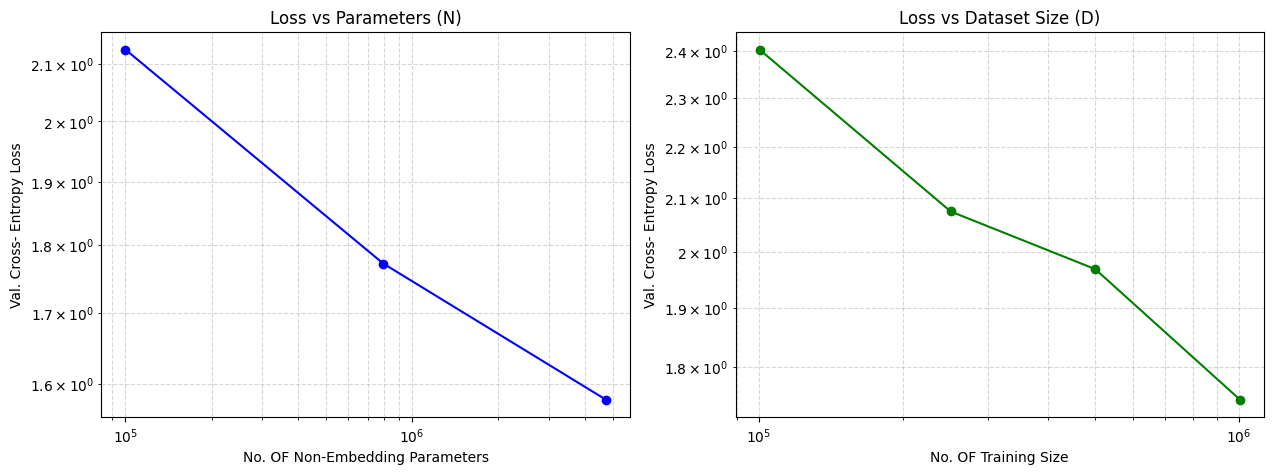

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].loglog(N_arr, L_N_arr, 'o-b')
ax[0].set_title('Loss vs Parameters (N)')
ax[0].set_xlabel('No. OF Non-Embedding Parameters')
ax[0].set_ylabel('Val. Cross- Entropy Loss')
ax[0].grid(True, which="both", ls="--", alpha=0.5)

ax[1].loglog(D_arr, L_D_arr, 'o-g')
ax[1].set_title('Loss vs Dataset Size (D)')
ax[1].set_xlabel('No. OF Training Size')
ax[1].set_ylabel('Val. Cross- Entropy Loss')
ax[1].grid(True, which="both", ls="--", alpha=0.5)
plt.savefig('scaling_laws.png', dpi=300)
plt.show()